# Practical Demo for `ellphi-alpha`

This is the canonical user notebook for `ellphi-alpha`: one place for core numeric checks and visual intuition.


## Setup


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

# Make local package import reliable when running from repo root.
repo_root = Path.cwd()
src_dir = repo_root / "src"
if src_dir.exists() and str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

import ellphi
import ellphi_alpha as ea

np.set_printoptions(precision=6, suppress=True)


def plot_level_sets(ax, centers, mats, alpha, title):
    # Plot level-set contours f_i(x) = alpha for anisotropic quadratic forms.
    centers = np.asarray(centers)
    mats = np.asarray(mats)
    mins = centers.min(axis=0) - 1.5
    maxs = centers.max(axis=0) + 1.5
    xs = np.linspace(mins[0], maxs[0], 220)
    ys = np.linspace(mins[1], maxs[1], 220)
    X, Y = np.meshgrid(xs, ys)
    grid = np.stack([X, Y], axis=-1)
    colors = plt.cm.tab10(np.linspace(0, 1, len(centers)))

    for idx, (center, mat, color) in enumerate(zip(centers, mats, colors)):
        delta = grid - center
        vals = np.einsum("...i,ij,...j->...", delta, mat, delta)
        if np.nanmin(vals) <= alpha <= np.nanmax(vals):
            ax.contour(X, Y, vals, levels=[alpha], colors=[color], linewidths=1.8)
        ax.scatter(center[0], center[1], color=color, s=40)
        ax.text(center[0] + 0.04, center[1] + 0.04, f"v{idx}", color=color)

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.axis("equal")
    ax.grid(alpha=0.25)


## Example A: Pairwise alpha correspondence

For a 2-vertex simplex, `alpha` from `ellphi_alpha` should match `ellphi.tangency(...).t**2`.


In [2]:
centers_A = np.array([
    [0.0, 0.0],
    [1.2, 0.6],
])
covs_A = np.array([
    [[0.45, 0.05], [0.05, 0.25]],
    [[0.30, -0.02], [-0.02, 0.55]],
])
mats_A = np.linalg.inv(covs_A)

p = ellphi.coef_from_cov(centers_A[0], covs_A[0])[0]
q = ellphi.coef_from_cov(centers_A[1], covs_A[1])[0]

pair = ea.solve_minimax_from_coefs(np.stack([p, q]), tol=1e-12)
tang = ellphi.tangency(p, q)

print("alpha({0,1}) from minimax =", pair.alpha)
print("t from ellphi =", tang.t)
print("t**2 from ellphi =", tang.t**2)
print("absolute difference =", abs(pair.alpha - tang.t**2))
print("circumcenter =", pair.circumcenter)
print("weights =", pair.weights)


alpha({0,1}) from minimax = 1.1588753467747448
t from ellphi = 1.076510727663568
t**2 from ellphi = 1.1588753467747446
absolute difference = 2.220446049250313e-16
circumcenter = [0.692044 0.228959]
weights = [0.542606 0.457394]


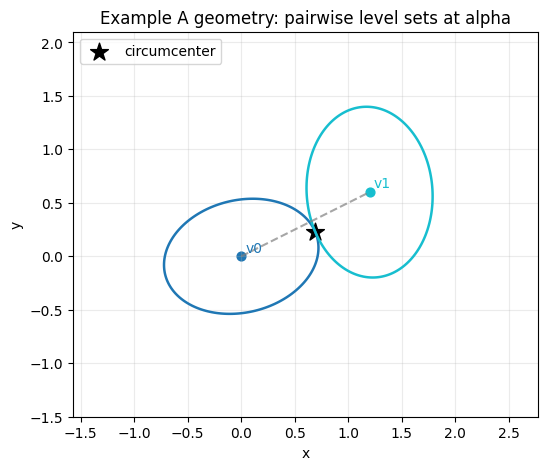

In [3]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_level_sets(
    ax,
    centers_A,
    mats_A,
    pair.alpha,
    title="Example A geometry: pairwise level sets at alpha",
)
ax.scatter(
    pair.circumcenter[0],
    pair.circumcenter[1],
    marker="*",
    s=180,
    color="black",
    label="circumcenter",
)
ax.plot(centers_A[:, 0], centers_A[:, 1], "--", color="gray", alpha=0.7)
ax.legend(loc="upper left")
plt.show()


## Example B: Small anisotropic simplex (`|sigma| = 3`)

Compute minimax on a triangle with different SPD matrices, inspect active constraints, and visualize the geometry.


In [4]:
centers_B = np.array([
    [0.0, 0.0],
    [2.0, 0.25],
    [0.7, 1.75],
])
covs_B = np.array([
    [[0.55, 0.08], [0.08, 0.30]],
    [[0.40, -0.06], [-0.06, 0.70]],
    [[0.75, 0.12], [0.12, 0.45]],
])
mats_B = np.linalg.inv(covs_B)

res_B = ea.solve_minimax(mats_B, centers_B, tol=1e-11)
diff_B = res_B.circumcenter[np.newaxis, :] - centers_B
fvals_B = np.einsum("ki,kij,kj->k", diff_B, mats_B, diff_B)

print("alpha(triangle) =", res_B.alpha)
print("converged =", res_B.converged, "iterations =", res_B.n_iter)
print("circumcenter =", res_B.circumcenter)
print("weights =", res_B.weights)
print("active_set =", res_B.active_set)
print("f_i(circumcenter) =", fvals_B)
print("max(f_i) - alpha =", np.max(fvals_B) - res_B.alpha)


alpha(triangle) = 2.8148325408804484
converged = True iterations = 32
circumcenter = [0.964445 0.709509]
weights = [0.357457 0.307888 0.334655]
active_set = [0, 1, 2]
f_i(circumcenter) = [2.814833 2.814833 2.814833]
max(f_i) - alpha = 0.0


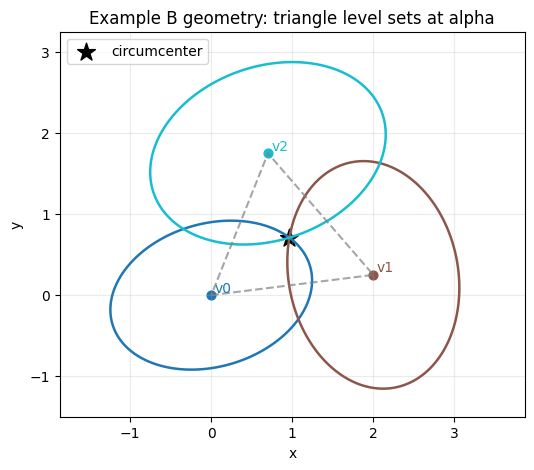

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_level_sets(
    ax,
    centers_B,
    mats_B,
    res_B.alpha,
    title="Example B geometry: triangle level sets at alpha",
)
ax.scatter(
    res_B.circumcenter[0],
    res_B.circumcenter[1],
    marker="*",
    s=180,
    color="black",
    label="circumcenter",
)
polygon = np.vstack([centers_B, centers_B[0]])
ax.plot(polygon[:, 0], polygon[:, 1], "--", color="gray", alpha=0.7)
ax.legend(loc="upper left")
plt.show()


## Example C: Incremental filtration and graph snapshot

Build a small filtration up to dimension 2, inspect top entries, and visualize accepted edges up to a chosen alpha threshold.


In [6]:
centers_C = np.array([
    [0.0, 0.0],
    [1.8, 0.1],
    [0.3, 1.6],
    [1.4, 1.4],
    [0.9, 0.7],
])
covs_C = np.array([
    [[0.55, 0.05], [0.05, 0.30]],
    [[0.45, -0.03], [-0.03, 0.60]],
    [[0.70, 0.08], [0.08, 0.40]],
    [[0.35, 0.02], [0.02, 0.50]],
    [[0.50, 0.00], [0.00, 0.45]],
])
mats_C = np.linalg.inv(covs_C)

filtration = ea.build_incremental_filtration(mats_C, centers_C, max_dim=2)

print("total filtration entries =", len(filtration))
counts = {}
for entry in filtration:
    dim = len(entry.simplex) - 1
    counts[dim] = counts.get(dim, 0) + 1
print("counts by simplex dimension =", counts)

print("\nTop 12 entries (simplex, alpha):")
for idx, entry in enumerate(filtration[:12], start=1):
    print(f"{idx:2d}. {entry.simplex} -> alpha={entry.alpha:.8f}")


total filtration entries = 13
counts by simplex dimension = {0: 5, 1: 6, 2: 2}

Top 12 entries (simplex, alpha):
 1. (0,) -> alpha=0.00000000
 2. (1,) -> alpha=0.00000000
 3. (2,) -> alpha=0.00000000
 4. (3,) -> alpha=0.00000000
 5. (4,) -> alpha=0.00000000
 6. (3, 4) -> alpha=0.39648718
 7. (1, 4) -> alpha=0.58213779
 8. (2, 3) -> alpha=0.64150565
 9. (2, 4) -> alpha=0.67394835
10. (0, 4) -> alpha=0.67453365
11. (2, 3, 4) -> alpha=0.80589926
12. (1, 3) -> alpha=0.86589459


alpha threshold (60th percentile of edge alpha) = 0.673948
accepted edges = 4 / 6


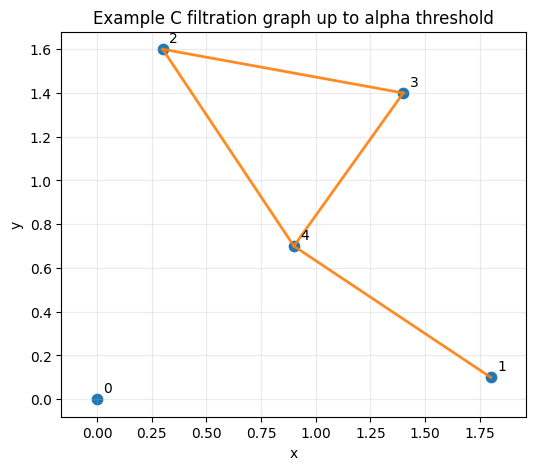

In [7]:
edge_entries = [entry for entry in filtration if len(entry.simplex) == 2]
edge_alphas = np.array([entry.alpha for entry in edge_entries])
alpha_threshold = float(np.quantile(edge_alphas, 0.6))
accepted_edges = [entry for entry in edge_entries if entry.alpha <= alpha_threshold + 1e-12]

print(f"alpha threshold (60th percentile of edge alpha) = {alpha_threshold:.6f}")
print(f"accepted edges = {len(accepted_edges)} / {len(edge_entries)}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(centers_C[:, 0], centers_C[:, 1], s=55, color="#1f77b4")
for idx, pt in enumerate(centers_C):
    ax.text(pt[0] + 0.03, pt[1] + 0.03, str(idx), fontsize=10)

for entry in accepted_edges:
    i, j = entry.simplex
    xy = centers_C[[i, j]]
    ax.plot(xy[:, 0], xy[:, 1], color="#ff7f0e", linewidth=2, alpha=0.9)

ax.set_title("Example C filtration graph up to alpha threshold")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.axis("equal")
ax.grid(alpha=0.25)
plt.show()


## Example D (optional): GUDHI persistence summary

If `gudhi` is available, export to a simplex tree and visualize finite H1 lifetimes.


GUDHI available: yes
H0 interval count = 5
H1 interval count = 2
largest finite H1 lifetimes = [0.131951 0.000094]


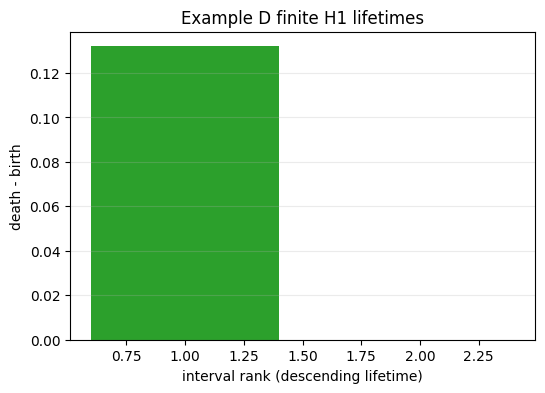

In [8]:
from ellphi_alpha.backends import GudhiBackend

backend = GudhiBackend()
if backend.is_available():
    st = ea.to_gudhi_simplex_tree(filtration)
    h0 = backend.persistence_intervals(st, dimension=0)
    h1 = backend.persistence_intervals(st, dimension=1)

    print("GUDHI available: yes")
    print("H0 interval count =", len(h0))
    print("H1 interval count =", len(h1))

    finite_h1 = h1[np.isfinite(h1[:, 1])] if len(h1) else np.empty((0, 2))
    if len(finite_h1):
        lifetimes = finite_h1[:, 1] - finite_h1[:, 0]
        order = np.argsort(lifetimes)[::-1]
        lifetimes = lifetimes[order]

        print("largest finite H1 lifetimes =", lifetimes[:3])

        fig, ax = plt.subplots(figsize=(6, 4))
        bars = np.arange(1, len(lifetimes) + 1)
        ax.bar(bars, lifetimes, color="#2ca02c")
        ax.set_title("Example D finite H1 lifetimes")
        ax.set_xlabel("interval rank (descending lifetime)")
        ax.set_ylabel("death - birth")
        ax.grid(axis="y", alpha=0.25)
        plt.show()
    else:
        print("No finite H1 intervals in this tiny example.")
else:
    print("GUDHI available: no")
    print("Skipping persistence plot. Install optional demo deps: poetry install --with demo")
